In [3]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\ZEUS\Documents\carbon_aware_marine_ai")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
EMISSIONS_DIR = OUTPUTS_DIR / "emissions"
CLOUD_SIM_DIR = OUTPUTS_DIR / "cloud_simulation"

FIGURES_DIR = PROJECT_ROOT / "figures"

for folder in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    METRICS_DIR,
    EMISSIONS_DIR,
    CLOUD_SIM_DIR,
    FIGURES_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)
print("Figures folder:", FIGURES_DIR)

Project root: C:\Users\ZEUS\Documents\carbon_aware_marine_ai
Raw data folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\raw
Figures folder: C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures


In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
# Study region: South Florida Atlantic Coast
# This region covers the Atlantic-side coastal waters from the Biscayne/Miami area
# up toward West Palm Beach. It avoids the Gulf of Mexico completely.

REGION_NAME = "south_florida_atlantic_coast"

LAT_MIN = 25.2
LAT_MAX = 27.0

# NOAA OISST uses longitude values from 0 to 360.
# -80.6 W = 279.4 E
# -79.0 W = 281.0 E
LON_MIN = 279.4
LON_MAX = 281.0

START_DATE = "2016-01-01"
END_DATE = "2024-12-31"

print("Research region:", REGION_NAME)
print("Latitude range:", LAT_MIN, "to", LAT_MAX)
print("Longitude range:", LON_MIN, "to", LON_MAX)
print("Date range:", START_DATE, "to", END_DATE)

Research region: south_florida_atlantic_coast
Latitude range: 25.2 to 27.0
Longitude range: 279.4 to 281.0
Date range: 2016-01-01 to 2024-12-31


In [6]:
OISST_URL = "https://www.ncei.noaa.gov/erddap/griddap/ncdc_oisst_v2_avhrr_by_time_zlev_lat_lon"

ds = xr.open_dataset(OISST_URL)

print("NOAA OISST dataset opened successfully.")
print(ds)

NOAA OISST dataset opened successfully.
<xarray.Dataset> Size: 37GB
Dimensions:    (time: 2237, depth: 1, latitude: 720, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 18kB 2020-02-28T12:00:00 ... 2026-04-13T...
  * depth      (depth) float32 4B 0.0
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
Data variables:
    ice        (time, depth, latitude, longitude) float32 9GB ...
    err        (time, depth, latitude, longitude) float32 9GB ...
    anom       (time, depth, latitude, longitude) float32 9GB ...
    sst        (time, depth, latitude, longitude) float32 9GB ...
Attributes: (12/46)
    _CoordSysBuilder:           ucar.nc2.dataset.conv.CF1Convention
    cdm_data_type:              Grid
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    Conventions:                CF-1.4, ACDD-1.3
    creator_email:              ois

In [11]:
test_subset = ds["sst"].sel(
    time=slice("2021-01-01", "2021-01-31"),
    latitude=slice(LAT_MIN, LAT_MAX),
    longitude=slice(LON_MIN, LON_MAX)
).isel(depth=0)

print(test_subset)

<xarray.DataArray 'sst' (time: 31, latitude: 7, longitude: 6)> Size: 5kB
[1302 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 248B 2021-01-01T12:00:00 ... 2021-01-31T...
  * latitude   (latitude) float32 28B 25.38 25.62 25.88 26.12 26.38 26.62 26.88
  * longitude  (longitude) float32 24B 279.6 279.9 280.1 280.4 280.6 280.9
    depth      float32 4B 0.0
Attributes:
    _ChunkSizes:  [   1    1  720 1440]
    long_name:    Daily sea surface temperature
    units:        Celsius
    valid_max:    4500.0
    valid_min:    -300.0


In [12]:
test_subset_loaded = test_subset.load()

test_output_path = RAW_DATA_DIR / "oisst_south_florida_atlantic_coast_test_2021_01.nc"

test_subset_loaded.to_netcdf(test_output_path)

print("Saved test file to:")
print(test_output_path)
print("File exists:", test_output_path.exists())
print("Shape:", test_subset_loaded.shape)

Saved test file to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\raw\oisst_south_florida_atlantic_coast_test_2021_01.nc
File exists: True
Shape: (31, 7, 6)


In [13]:
print("Dataset dimensions:")
print(ds.dims)

print("\nDataset coordinates:")
print(ds.coords)

print("\nSST variable:")
print(ds["sst"])

Dataset dimensions:
FrozenMappingWarningOnValuesAccess({'time': 2237, 'depth': 1, 'latitude': 720, 'longitude': 1440})

Dataset coordinates:
Coordinates:
  * time       (time) datetime64[ns] 18kB 2020-02-28T12:00:00 ... 2026-04-13T...
  * depth      (depth) float32 4B 0.0
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9

SST variable:
<xarray.DataArray 'sst' (time: 2237, depth: 1, latitude: 720, longitude: 1440)> Size: 9GB
[2319321600 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 18kB 2020-02-28T12:00:00 ... 2026-04-13T...
  * depth      (depth) float32 4B 0.0
  * latitude   (latitude) float32 3kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * longitude  (longitude) float32 6kB 0.125 0.375 0.625 ... 359.4 359.6 359.9
Attributes:
    _ChunkSizes:  [   1    1  720 1440]
    long_name:    Daily sea surface temperature
    units:        Celsius
    v

In [14]:
START_DATE = "2021-01-01"
END_DATE = "2024-12-31"

full_subset = ds["sst"].sel(
    time=slice(START_DATE, END_DATE),
    latitude=slice(LAT_MIN, LAT_MAX),
    longitude=slice(LON_MIN, LON_MAX)
).isel(depth=0)

print(full_subset)

<xarray.DataArray 'sst' (time: 1461, latitude: 7, longitude: 6)> Size: 245kB
[61362 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 12kB 2021-01-01T12:00:00 ... 2024-12-31T...
  * latitude   (latitude) float32 28B 25.38 25.62 25.88 26.12 26.38 26.62 26.88
  * longitude  (longitude) float32 24B 279.6 279.9 280.1 280.4 280.6 280.9
    depth      float32 4B 0.0
Attributes:
    _ChunkSizes:  [   1    1  720 1440]
    long_name:    Daily sea surface temperature
    units:        Celsius
    valid_max:    4500.0
    valid_min:    -300.0


In [15]:
full_subset_loaded = full_subset.load()

full_output_path = RAW_DATA_DIR / "oisst_south_florida_atlantic_coast_2021_2024.nc"

full_subset_loaded.to_netcdf(full_output_path)

print("Full dataset saved to:")
print(full_output_path)
print("File exists:", full_output_path.exists())
print("Shape:", full_subset_loaded.shape)

Full dataset saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\raw\oisst_south_florida_atlantic_coast_2021_2024.nc
File exists: True
Shape: (1461, 7, 6)


In [16]:
# Full research subset
# Study region: South Florida Atlantic Coast from Biscayne/Miami to West Palm Beach
# Dataset range: 2021–2024

START_DATE = "2021-01-01"
END_DATE = "2024-12-31"

full_subset = ds["sst"].sel(
    time=slice(START_DATE, END_DATE),
    latitude=slice(LAT_MIN, LAT_MAX),
    longitude=slice(LON_MIN, LON_MAX)
).isel(depth=0)

print("Full subset selected successfully.")
print(full_subset)

Full subset selected successfully.
<xarray.DataArray 'sst' (time: 1461, latitude: 7, longitude: 6)> Size: 245kB
[61362 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 12kB 2021-01-01T12:00:00 ... 2024-12-31T...
  * latitude   (latitude) float32 28B 25.38 25.62 25.88 26.12 26.38 26.62 26.88
  * longitude  (longitude) float32 24B 279.6 279.9 280.1 280.4 280.6 280.9
    depth      float32 4B 0.0
Attributes:
    _ChunkSizes:  [   1    1  720 1440]
    long_name:    Daily sea surface temperature
    units:        Celsius
    valid_max:    4500.0
    valid_min:    -300.0


In [17]:
# Loading the selected SST subset into memory
full_subset_loaded = full_subset.load()

# Saving inside the correct project folder
full_output_path = RAW_DATA_DIR / "oisst_south_florida_atlantic_coast_2021_2024.nc"

full_subset_loaded.to_netcdf(full_output_path)

print("Full dataset saved to:")
print(full_output_path)
print("File exists:", full_output_path.exists())
print("Shape:", full_subset_loaded.shape)

print("\nTime range:")
print(str(full_subset_loaded.time.values[0]), "to", str(full_subset_loaded.time.values[-1]))

print("\nLatitude range:")
print(float(full_subset_loaded.latitude.min()), "to", float(full_subset_loaded.latitude.max()))

print("\nLongitude range:")
print(float(full_subset_loaded.longitude.min()), "to", float(full_subset_loaded.longitude.max()))

print("\nSST value range:")
print(float(full_subset_loaded.min(skipna=True)), "to", float(full_subset_loaded.max(skipna=True)))

Full dataset saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\raw\oisst_south_florida_atlantic_coast_2021_2024.nc
File exists: True
Shape: (1461, 7, 6)

Time range:
2021-01-01T12:00:00.000000000 to 2024-12-31T12:00:00.000000000

Latitude range:
25.375 to 26.875

Longitude range:
279.625 to 280.875

SST value range:
22.189998626708984 to 32.04999923706055


In [18]:
# Checking missing values in the SST subset
total_values = full_subset_loaded.size
missing_values = int(full_subset_loaded.isnull().sum().values)
missing_percent = (missing_values / total_values) * 100

print("Total values:", total_values)
print("Missing values:", missing_values)
print("Missing percentage:", round(missing_percent, 2), "%")

Total values: 61362
Missing values: 14610
Missing percentage: 23.81 %


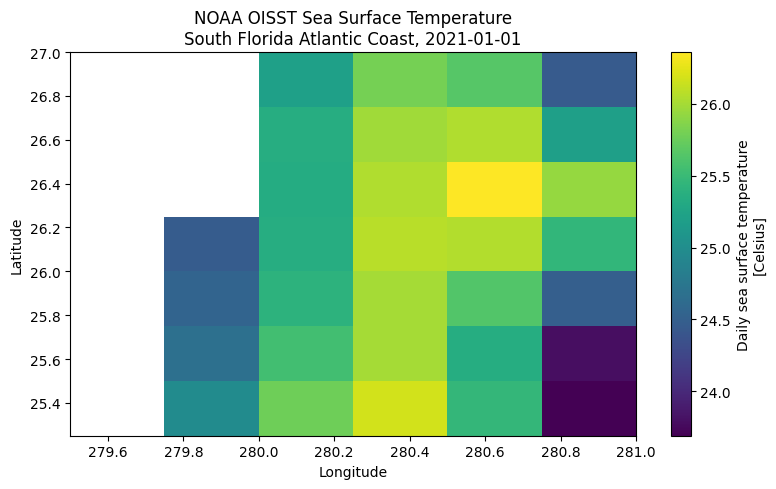

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\sst_sample_map_south_florida_atlantic_2021_01_01.png
File exists: True


In [19]:
# Selecting one sample day for a spatial SST map
sample_day = full_subset_loaded.sel(time="2021-01-01", method="nearest")

plt.figure(figsize=(8, 5))
sample_day.plot()

plt.title("NOAA OISST Sea Surface Temperature\nSouth Florida Atlantic Coast, 2021-01-01")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()

figure_path = FIGURES_DIR / "sst_sample_map_south_florida_atlantic_2021_01_01.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

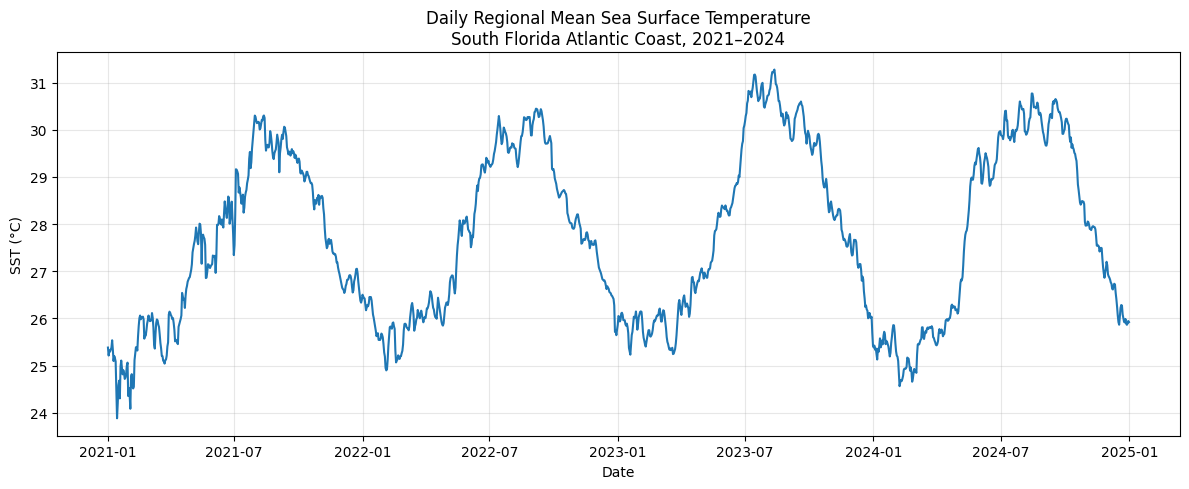

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\sst_regional_mean_south_florida_atlantic_2021_2024.png
File exists: True


In [20]:
# Calculating daily regional mean SST across latitude and longitude
regional_mean_sst = full_subset_loaded.mean(dim=["latitude", "longitude"], skipna=True)

plt.figure(figsize=(12, 5))
plt.plot(regional_mean_sst.time.values, regional_mean_sst.values)

plt.title("Daily Regional Mean Sea Surface Temperature\nSouth Florida Atlantic Coast, 2021–2024")
plt.xlabel("Date")
plt.ylabel("SST (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "sst_regional_mean_south_florida_atlantic_2021_2024.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

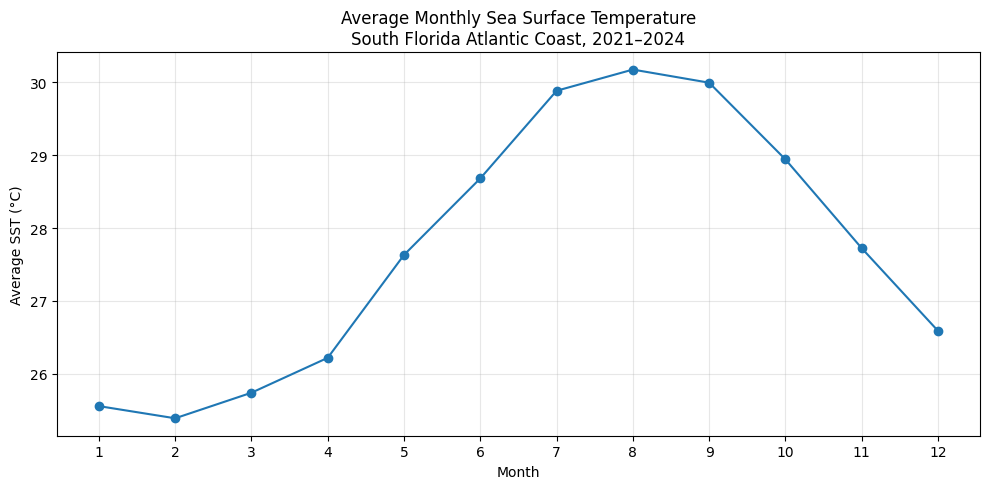

Saved figure to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\figures\sst_monthly_pattern_south_florida_atlantic_2021_2024.png
File exists: True


In [21]:
# Converting regional mean SST to a DataFrame for monthly analysis
regional_mean_df = regional_mean_sst.to_dataframe(name="sst").reset_index()

# Creating month column
regional_mean_df["month"] = regional_mean_df["time"].dt.month

# Calculating average SST for each month
monthly_mean_sst = regional_mean_df.groupby("month")["sst"].mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_mean_sst.index, monthly_mean_sst.values, marker="o")

plt.title("Average Monthly Sea Surface Temperature\nSouth Florida Atlantic Coast, 2021–2024")
plt.xlabel("Month")
plt.ylabel("Average SST (°C)")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURES_DIR / "sst_monthly_pattern_south_florida_atlantic_2021_2024.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:")
print(figure_path)
print("File exists:", figure_path.exists())

In [22]:
# Saving the regional mean SST time series for later use
regional_mean_output_path = PROCESSED_DATA_DIR / "regional_mean_sst_south_florida_atlantic_2021_2024.csv"

regional_mean_df.to_csv(regional_mean_output_path, index=False)

print("Regional mean SST CSV saved to:")
print(regional_mean_output_path)
print("File exists:", regional_mean_output_path.exists())

regional_mean_df.head()

Regional mean SST CSV saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\data\processed\regional_mean_sst_south_florida_atlantic_2021_2024.csv
File exists: True


,time,depth,sst,month
0,2021-01-01 12:00:00,0.0,25.381561,1
1,2021-01-02 12:00:00,0.0,25.212502,1
2,2021-01-03 12:00:00,0.0,25.319376,1
3,2021-01-04 12:00:00,0.0,25.296560,1
4,2021-01-05 12:00:00,0.0,25.340937,1


In [23]:
# Final validation summary for Notebook 02

valid_cell_count = int(full_subset_loaded.notnull().any(dim="time").sum().values)
total_grid_cells = full_subset_loaded.sizes["latitude"] * full_subset_loaded.sizes["longitude"]

summary = {
    "region_name": REGION_NAME,
    "start_date": str(full_subset_loaded.time.values[0]),
    "end_date": str(full_subset_loaded.time.values[-1]),
    "latitude_min": float(full_subset_loaded.latitude.min()),
    "latitude_max": float(full_subset_loaded.latitude.max()),
    "longitude_min_0_360": float(full_subset_loaded.longitude.min()),
    "longitude_max_0_360": float(full_subset_loaded.longitude.max()),
    "total_days": full_subset_loaded.sizes["time"],
    "latitude_points": full_subset_loaded.sizes["latitude"],
    "longitude_points": full_subset_loaded.sizes["longitude"],
    "total_grid_cells": total_grid_cells,
    "valid_ocean_grid_cells": valid_cell_count,
    "missing_percentage": round(missing_percent, 2),
    "sst_min_celsius": float(full_subset_loaded.min(skipna=True)),
    "sst_max_celsius": float(full_subset_loaded.max(skipna=True)),
}

summary_df = pd.DataFrame([summary])

summary_output_path = OUTPUTS_DIR / "dataset_summary_south_florida_atlantic_2021_2024.csv"
summary_df.to_csv(summary_output_path, index=False)

print("Dataset summary saved to:")
print(summary_output_path)
print("File exists:", summary_output_path.exists())

summary_df

Dataset summary saved to:
C:\Users\ZEUS\Documents\carbon_aware_marine_ai\outputs\dataset_summary_south_florida_atlantic_2021_2024.csv
File exists: True


,region_name,start_date,end_date,latitude_min,latitude_max,longitude_min_0_360,longitude_max_0_360,total_days,latitude_points,longitude_points,total_grid_cells,valid_ocean_grid_cells,missing_percentage,sst_min_celsius,sst_max_celsius
0,south_florida_atlantic_coast,2021-01-01T12:00:00.000000000,2024-12-31T12:00:00.000000000,25.375,26.875,279.625,280.875,1461,7,6,42,32,23.81,22.189999,32.049999
